In [1]:
import IJulia
import Base64

# The julia kernel has built in support for Revise.jl, so this is the 
# recommended approach for long-running sessions:
# https://github.com/JuliaLang/IJulia.jl/blob/9b10fa9b879574bbf720f5285029e07758e50a5e/src/kernel.jl#L46-L51

# Users should enable revise within .julia/config/startup_ijulia.jl:
# https://timholy.github.io/Revise.jl/stable/config/#Using-Revise-automatically-within-Jupyter/IJulia-1

# clear console history
IJulia.clear_history()

fig_width = 7
fig_height = 5
fig_format = :retina
fig_dpi = 96

# no retina format type, use svg for high quality type/marks
if fig_format == :retina
  fig_format = :svg
elseif fig_format == :pdf
  fig_dpi = 96
  # Enable PDF support for IJulia
  IJulia.register_mime(MIME("application/pdf"))
end

# convert inches to pixels
fig_width = fig_width * fig_dpi
fig_height = fig_height * fig_dpi

# Intialize Plots w/ default fig width/height
try
  import Plots

  # Plots.jl doesn't support PDF output for versions < 1.28.1
  # so use png (if the DPI remains the default of 300 then set to 96)
  if (Plots._current_plots_version < v"1.28.1") & (fig_format == :pdf)
    Plots.gr(size=(fig_width, fig_height), fmt = :png, dpi = fig_dpi)
  else
    Plots.gr(size=(fig_width, fig_height), fmt = fig_format, dpi = fig_dpi)
  end
catch e
  # @warn "Plots init" exception=(e, catch_backtrace())
end

# Initialize CairoMakie with default fig width/height
try
  import CairoMakie

  # CairoMakie's display() in PDF format opens an interactive window
  # instead of saving to the ipynb file, so we don't do that.
  # https://github.com/quarto-dev/quarto-cli/issues/7548
  if fig_format == :pdf
    CairoMakie.activate!(type = "png")
  else
    CairoMakie.activate!(type = string(fig_format))
  end
  CairoMakie.update_theme!(resolution=(fig_width, fig_height))
catch e
    # @warn "CairoMakie init" exception=(e, catch_backtrace())
end
  
# Set run_path if specified
try
  run_path = "QzpcVXNlcnNcTmlrb2xhalxHaXRcZ3JhcGgtZXF1aWxpYnJpdW0tcmFkaWF0aXZlLXRyYW5zZmVyXGV4YW1wbGVz"
  if !isempty(run_path)
    run_path = String(Base64.base64decode(run_path))
    cd(run_path)
  end
catch e
  @warn "Run path init:" exception=(e, catch_backtrace())
end


# emulate old Pkg.installed beahvior, see
# https://discourse.julialang.org/t/how-to-use-pkg-dependencies-instead-of-pkg-installed/36416/9
import Pkg
function isinstalled(pkg::String)
  any(x -> x.name == pkg && x.is_direct_dep, values(Pkg.dependencies()))
end

# ojs_define
if isinstalled("JSON") && isinstalled("DataFrames")
  import JSON, DataFrames
  global function ojs_define(; kwargs...)
    convert(x) = x
    convert(x::DataFrames.AbstractDataFrame) = Tables.rows(x)
    content = Dict("contents" => [Dict("name" => k, "value" => convert(v)) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
elseif isinstalled("JSON")
  import JSON
  global function ojs_define(; kwargs...)
    content = Dict("contents" => [Dict("name" => k, "value" => v) for (k, v) in kwargs])
    tag = "<script type='ojs-define'>$(JSON.json(content))</script>"
    IJulia.display(MIME("text/html"), tag)
  end
else
  global function ojs_define(; kwargs...)
    @warn "JSON package not available. Please install the JSON.jl package to use ojs_define."
  end
end


# don't return kernel dependencies (b/c Revise should take care of dependencies)
nothing


In [2]:
using RayTraceHeatTransfer
using GeometryBasics, StaticArrays
using ConvolutionInterpolations

function build_mesh(Ndim)                          # the Example 1 geometry and boundary conditions
    vertices = SVector(Point2(0.0, 0.0), Point2(1.0, 0.0), Point2(1.0, 1.0), Point2(0.0, 1.0))
    face = PolyVolume2D{Float64}(vertices, SVector(true, true, true, true), 1, 1.0, 0.0)   # κ = 1, σₛ = 0
    face.T_in_w  = [1000.0, 0.0, 0.0, 0.0]        # bottom hot, rest cold
    face.epsilon = [1.0, 1.0, 1.0, 1.0]            # black walls
    face.T_in_g  = -1.0                            # unknown gas temperature
    face.q_in_g  = 0.0                             # radiative equilibrium
    return RayTracingDomain2D([face], [(Ndim, Ndim)]; verbose = false)
end

# Crosbie & Schrenker (1984): optical depth from the hot wall, and the source function S there
tau_ref = [0.0, 0.00611, 0.02037, 0.04251, 0.07216, 0.10884, 0.15194,
           0.20076, 0.25449, 0.31225, 0.37309, 0.43602, 0.50000, 0.56398,
           0.62691, 0.68775, 0.74551, 0.79924, 0.84806, 0.89116, 0.92784,
           0.95749, 0.97963, 0.99390, 1.00000]
S_ref   = [0.6293, 0.6198, 0.6017, 0.5767, 0.5460, 0.5108, 0.4724,
           0.4323, 0.3919, 0.3525, 0.3153, 0.2810, 0.2500, 0.2224,
           0.1981, 0.1768, 0.1584, 0.1424, 0.1287, 0.1171, 0.1073,
           0.0992, 0.0930, 0.0885, 0.0863]
S_ref_itp = convolution_interpolation(tau_ref, S_ref; kernel = :b13)   # the reference as a function of optical depth

# Average of the reference over the row between optical depths a and b, by the midpoint rule
function row_average(a, b; n = 1000)
    width = (b - a) / n                                            # width of one subinterval
    total = sum(S_ref_itp(a + (k - 0.5) * width) for k in 1:n)     # the reference at every subinterval midpoint
    return total / n                                               # its mean over the row
end

row_average (generic function with 1 method)

In [3]:
# Rms deviation of the centreline source function from Crosbie & Schrenker, for the Example 1
# problem on an Ndim × Ndim mesh, traced with `rays` rays by the given tracer and sampler
function centreline_deviation(Ndim, rays; method = :pathlength, sampler = :sobol)
    mesh = build_mesh(Ndim)                                              # the Example 1 geometry and boundary conditions
    mesh(rays; method = method, sampler = sampler, verbose = false)      # exchange factors by ray tracing
    smooth!(mesh; verbose = false)                                       # enforce reciprocity and energy conservation
    solveEquilibrium!(mesh, mesh.F_smooth; verbose = false)              # solve for the gas temperatures

    T = reshape([cell.T_g for cell in mesh.fine_mesh[1]], Ndim, Ndim)    # temperatures as T[column, row], rows from the hot wall
    S = (T ./ 1000.0) .^ 4                                               # dimensionless source function, T_hot = 1000 K
    c = div(Ndim + 1, 2)                                                 # the centre column

    # A cell average lies below the centreline value by h²/24 times the curvature across the
    # centreline, which the second difference of the three middle columns approximates: remove it
    S_centre = S[c, :] .- (S[c-1, :] .- 2 .* S[c, :] .+ S[c+1, :]) ./ 24

    edges = range(0, 1, length = Ndim + 1)                               # optical depth at the row boundaries
    S_ref_rows = [row_average(edges[j], edges[j+1]) for j in 1:Ndim]     # the reference averaged over each row
    return sqrt(sum(abs2, S_centre .- S_ref_rows) / Ndim)                # rms deviation along the centreline
end

centreline_deviation (generic function with 1 method)

In [4]:
# The three ways of computing the exchange factors: tracer, sampler, and a label for the figure
configurations = [(:exchange,   :random, "exchange, pseudorandom"),
                  (:exchange,   :sobol,  "exchange, Sobol"),
                  (:pathlength, :sobol,  "pathlength, Sobol")]

Ndim_rays        = 11                                        # the mesh for the ray study
emitters         = 4Ndim_rays + Ndim_rays^2                  # 44 wall elements and 121 cells emit rays
rays_per_emitter = [2^10, 2^12, 2^14, 2^16, 2^18]            # powers of two, which suit Sobol sampling

# rms deviation for every configuration (rows) and number of rays per emitter (columns)
ray_study = [centreline_deviation(Ndim_rays, emitters * r; method = m, sampler = s)
             for (m, s, _) in configurations, r in rays_per_emitter]

3×5 Matrix{Float64}:
 0.00934958  0.00308951   0.00235096   0.00116278   0.000655432
 0.00434498  0.00106613   0.000439506  0.00041434   0.000328835
 0.00106498  0.000671052  0.000323661  0.000350512  0.000344583

In [5]:
meshes                = [7, 11, 15, 21]                      # cells per side, odd so that there is a centre column
mesh_rays_per_emitter = [2^15, 2^16, 2^17, 2^18]             # grows about as the number of cells, Ndim²
mesh_emitters         = [4n + n^2 for n in meshes]           # wall elements and cells on each mesh

# rms deviation for every configuration (rows) and mesh (columns)
mesh_study = [centreline_deviation(n, e * r; method = m, sampler = s)
              for (m, s, _) in configurations,
                  (n, e, r) in zip(meshes, mesh_emitters, mesh_rays_per_emitter)]

3×4 Matrix{Float64}:
 0.00197072   0.00116278   0.00095803   0.000528503
 0.000888643  0.00041434   0.000261269  0.000151196
 0.000764791  0.000350512  0.000178127  0.000109501

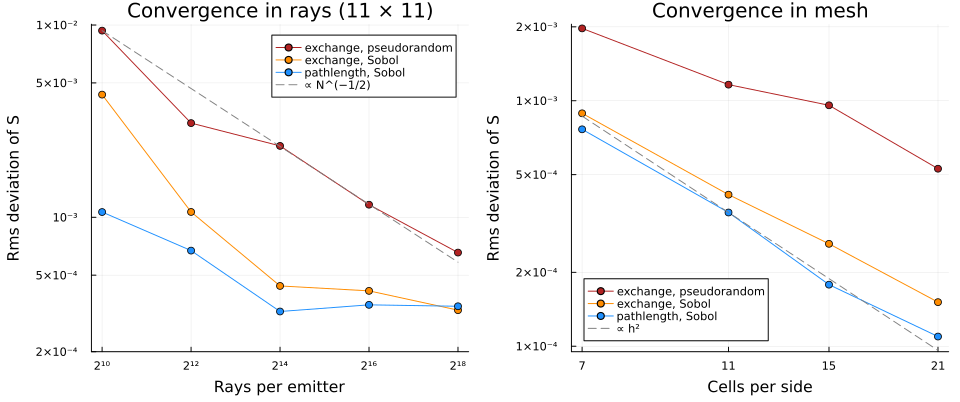

In [6]:
using Plots

colours = [:firebrick, :darkorange, :dodgerblue]                        # one colour per configuration

# Left panel: rms deviation against the number of rays per emitter, on the 11 × 11 mesh
p1 = Plots.plot(xscale = :log10, yscale = :log10,
    xticks = (rays_per_emitter, ["2¹⁰", "2¹²", "2¹⁴", "2¹⁶", "2¹⁸"]),  # label the ray counts as powers of two
    xlabel = "Rays per emitter", ylabel = "Rms deviation of S",
    ylims  = (2e-4, 1.01e-2),
    yticks = ([2e-4, 5e-4, 1e-3, 5e-3, 1e-2], ["2×10⁻⁴", "5×10⁻⁴", "10⁻³", "5×10⁻³", "1×10⁻²"]), # plain labels on the log axis
    title = "Convergence in rays (11 × 11)", legend = :topright)
for (k, (_, _, label)) in enumerate(configurations)                     # one line per configuration
    Plots.plot!(p1, rays_per_emitter, ray_study[k, :];
        marker = :circle, color = colours[k], label = label)
end
ray_guide = ray_study[1, 1] .* (rays_per_emitter ./ rays_per_emitter[1]) .^ (-1 / 2)   # ∝ N^(−1/2), from the first point
Plots.plot!(p1, rays_per_emitter, ray_guide;
   linestyle = :dash, color = :gray, label = "∝ N^(−1/2)")

# Right panel: rms deviation against the number of cells per side, rays growing with the mesh
p2 = Plots.plot(xscale = :log10, yscale = :log10,
    xticks = (meshes, string.(meshes)),                                 # label the meshes by cells per side
    xlabel = "Cells per side", ylabel = "Rms deviation of S",
    ylims  = (9.5e-5, 2.05e-3),
    yticks = ([1e-4, 2e-4, 5e-4, 1e-3, 2e-3], ["1×10⁻⁴", "2×10⁻⁴", "5×10⁻⁴", "1×10⁻³", "2×10⁻³"]), # plain labels on the log axis
    title = "Convergence in mesh", legend = :bottomleft)
for (k, (_, _, label)) in enumerate(configurations)                     # one line per configuration
    Plots.plot!(p2, meshes, mesh_study[k, :];
        marker = :circle, color = colours[k], label = label)
end
mesh_guide = mesh_study[3, 2] .* (meshes ./ 11) .^ (-2)                  # ∝ h², through the pathlength point on 11 × 11
Plots.plot!(p2, meshes, mesh_guide; linestyle = :dash, color = :gray, label = "∝ h²")

p = Plots.plot(p1, p2; layout = (1, 2), size = (1000, 420),             # both panels side by side
    left_margin = 5Plots.mm, bottom_margin = 5Plots.mm)
display(p)